In [1]:
import os
import sys

# 주피터 노트북 환경에서 __file__이 없으므로, 현재 워킹 디렉토리 기준으로 설정
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from data_scraping.common.data_loader import load_movie_data

movie_data = load_movie_data()

In [11]:
from modeling.models.clip.models.jina import JinaClipEncoder
from modeling.models.clip.models.openai import OpenAICLIPEncoder
from modeling.models.clip.models.openclip import OpenCLIPEncoder

jina_clip_enc = JinaClipEncoder()

# openclip_clip_enc = OpenCLIPEncoder(model_key='openclip-h14') # 이거 쓰면 컴퓨터 죽는다
openclip_clip_enc = OpenCLIPEncoder(model_key="openclip-b32")

openai_clip_enc = OpenAICLIPEncoder(model_key="openai-b16")

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
row = movie_data.iloc[0]
row

movie_id                                       292731
title                       The Monroy Affaire (2022)
genres                                          Drama
imdb_id                                    tt26812510
tmdb_id                                     1032473.0
adult                                           False
backdrop_path        /meFyMj4e1riRPEQTT2XvKJdYTFh.jpg
id                                            1032473
title_tmdb                             El caso Monroy
original_title                         El caso Monroy
overview                                             
poster_path          /eZzAPq72NhCZIgUzzmu3CWJdKCr.jpg
media_type                                      movie
original_language                                  es
genre_ids                                        [18]
popularity                                      1.316
release_date                               2022-10-06
video                                           False
vote_average                

In [4]:
import requests

size = "w300"
image_path = row["poster_path"]

base_url = "https://image.tmdb.org/t/p/"
url = f"{base_url}{size}{image_path}"

filename = image_path.lstrip("/").replace("/", "_")

resp = requests.get(url, timeout=10)
resp.raise_for_status()

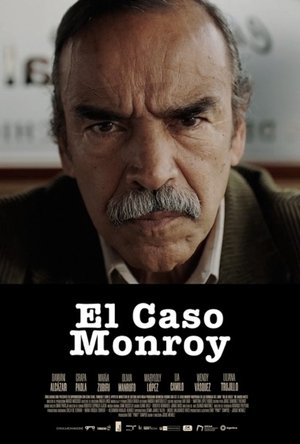

In [5]:
from io import BytesIO

from PIL import Image

content = resp.content  # bytes from requests response
image = Image.open(BytesIO(content))  # open image
image

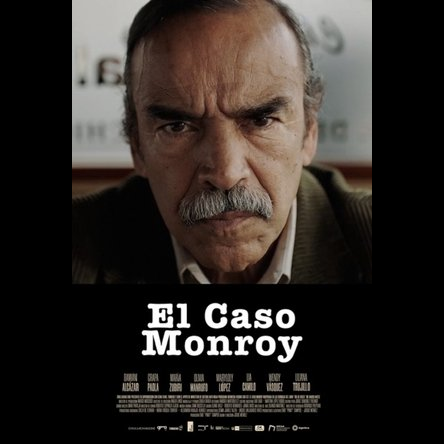

In [6]:
from modeling.models.clip.utils import make_square

make_square(image)

In [12]:
# 비교하고 싶은 인코더 클래스 인스턴스를 encoder_list에 넣으세요.
# 예시: encoder_list = [jina_clip_enc, openclip_clip_enc, openai_clip_enc]
encoder_list = [jina_clip_enc, openclip_clip_enc, openai_clip_enc]  # 필요한 인코더만 선택해서 넣으세요

texts = [
    # 청춘, 밝은 무드
    "경쾌한 청춘 코미디·드라마 느낌",
    "A lively youth comedy/drama vibe",  # 영어 번역
    "여러 명의 젊은 남녀가 함께 서 있는 그룹 샷",
    "A group shot of several young men and women standing together",
    "남녀가 함께 있는",
    "A man and a woman together",
    "여름 분위기, 해변 또는 축제 느낌",
    "A summer vibe, beach or festival feeling",
    "밝은 노란색/주황색 톤의 레트로 무드",
    "A retro mood with bright yellow/orange tones",
    "70s or retro fashion 스타일",
    "70s or retro fashion style",
    "음악/밴드 분위기 (기타, 악기 등 있음)",
    "Music/band atmosphere (with guitars or instruments)",
    "A cheerful and upbeat coming-of-age movie poster with a group of young friends standing together in colorful summer clothing.",
    "안녕",
    "Hello",
    # 진지하고 무거운 분위기
    "중년 또는 노년 남성의 진지한 얼굴 클로즈업",
    "Close-up of a serious-looking middle-aged or elderly man",
    "강렬한 눈빛, 무거운 표정",
    "Intense gaze, heavy expression",
    "어두운, 사실적인 톤 (crime / investigation 스타일)",
    "Dark, realistic tone (crime/investigation style)",
    "다큐멘터리 혹은 실화 기반 느낌",
    "Documentary or based-on-true-story feeling",
    "포스터 하단에 사건명 같은 타이틀 구성",
    "Poster layout with the case name as a title at the bottom",
    # 네거티브 샘플
    "여자가 웃고 있는 얼굴",
    "A smiling woman's face",
]

import torch.nn.functional as F

# 각 인코더별 이미지 임베딩 미리 계산
encoder_imgvecs = {}
for enc in encoder_list:
    encoder_imgvecs[enc.__class__.__name__] = enc.encode_image_from_bytes(content)

results = []
for text in texts:
    row_result = {"text": text}
    for enc in encoder_list:
        enc_name = enc.__class__.__name__
        text_vec = enc.encode_text(text)
        img_vec = encoder_imgvecs[enc_name]
        sim = F.cosine_similarity(text_vec, img_vec).item()
        row_result[enc_name] = sim
    results.append(row_result)

# 헤더 동적으로 구성
enc_names = [enc.__class__.__name__ for enc in encoder_list]
header = f"{'Text':<55} | " + " | ".join([f"{name:>12}" for name in enc_names])
print(header)
print("-" * (60 + 15 * len(enc_names)))
for item in results:
    txt_short = (item["text"][:50] + "...") if len(item["text"]) > 53 else item["text"]
    row_scores = " | ".join([f"{item[name]:12.4f}" for name in enc_names])
    print(f"{txt_short:<55} | {row_scores}")

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Text                                                    | JinaClipEncoder | OpenCLIPEncoder | OpenAICLIPEncoder
---------------------------------------------------------------------------------------------------------
경쾌한 청춘 코미디·드라마 느낌                                       |       0.1033 |       0.1663 |       0.1928
A lively youth comedy/drama vibe                        |       0.0181 |       0.1637 |       0.2341
여러 명의 젊은 남녀가 함께 서 있는 그룹 샷                               |       0.0879 |       0.1800 |       0.1869
A group shot of several young men and women standi...   |      -0.0199 |       0.0604 |       0.1448
남녀가 함께 있는                                               |       0.0985 |       0.1954 |       0.1935
A man and a woman together                              |       0.0112 |       0.1159 |       0.1971
여름 분위기, 해변 또는 축제 느낌                                     |       0.0979 |       0.1554 |       0.1141
A summer vibe, beach or festival feeling                |      -0.0760 |   